In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Load the dataset
file_path = r"C:\Users\Tim\kinase_interactions.csv"
data = pd.read_csv(file_path)

# Step 2: Inspect the dataset
print("Dataset Head:")
print(data.head())

Dataset Head:
  Kinase        Source Protein        Target Protein  Interaction Score
0  AURKA  9606.ENSP00000216911  9606.ENSP00000288207              0.988
1  AURKA  9606.ENSP00000216911  9606.ENSP00000368759              0.990
2  AURKA  9606.ENSP00000216911  9606.ENSP00000301633              0.993
3  AURKA  9606.ENSP00000216911  9606.ENSP00000378295              0.994
4  AURKA  9606.ENSP00000216911  9606.ENSP00000361540              0.995


In [10]:
print("\nDataset Summary:")
print(data.info())


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kinase             869 non-null    object 
 1   Source Protein     869 non-null    object 
 2   Target Protein     869 non-null    object 
 3   Interaction Score  869 non-null    float64
dtypes: float64(1), object(3)
memory usage: 27.3+ KB
None


In [11]:
# Step 3: Filter for high-confidence interactions
confidence_threshold = 0.7  # Adjust this value as needed
filtered_data = data[data["Interaction Score"].astype(float) >= confidence_threshold]
print(f"\nNumber of interactions above {confidence_threshold}: {len(filtered_data)}")


Number of interactions above 0.7: 869


In [12]:
# Step 4: Create a NetworkX graph
graph = nx.Graph()

# Add edges (kinase interactions)
for _, row in filtered_data.iterrows():
    source = row["Source Protein"]
    target = row["Target Protein"]
    weight = float(row["Interaction Score"])
    graph.add_edge(source, target, weight=weight)

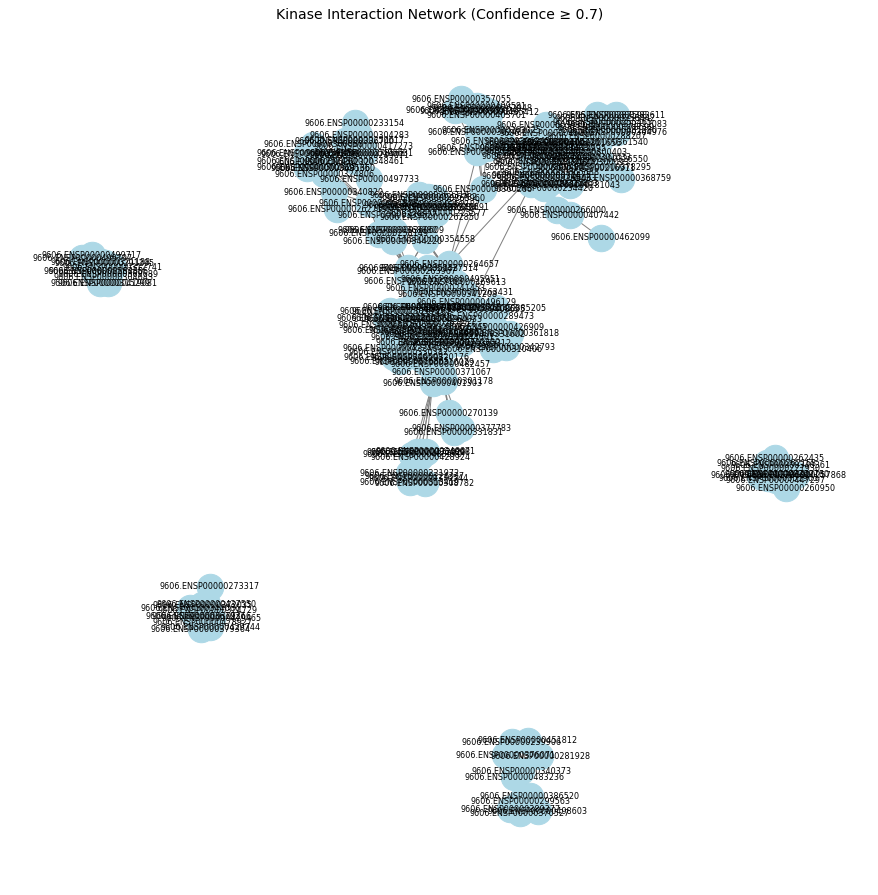

In [13]:
# Step 5: Visualize the network
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(graph)  # Layout for graph visualization
nx.draw(
    graph, 
    pos, 
    with_labels=True, 
    node_color="lightblue", 
    node_size=700, 
    edge_color="gray", 
    font_size=8
)
plt.title(f"Kinase Interaction Network (Confidence ≥ {confidence_threshold})", fontsize=14)
plt.show()

In [14]:
# Step 1: Calculate Centrality Measures
degree_centrality = nx.degree_centrality(graph)
betweenness_centrality = nx.betweenness_centrality(graph)
closeness_centrality = nx.closeness_centrality(graph)

In [16]:
# Step 2: Combine Results into a DataFrame
centrality_df = pd.DataFrame({
    "Node": list(degree_centrality.keys()),
    "Degree Centrality": list(degree_centrality.values()),
    "Betweenness Centrality": list(betweenness_centrality.values()),
    "Closeness Centrality": list(closeness_centrality.values())
})

In [17]:
# Sort by Degree Centrality for top influencers
centrality_df = centrality_df.sort_values(by="Degree Centrality", ascending=False)
print("\nTop 10 Nodes by Degree Centrality:")
print(centrality_df.head(10))


Top 10 Nodes by Degree Centrality:
                     Node  Degree Centrality  Betweenness Centrality  \
9    9606.ENSP00000269305           0.151961                0.222061   
26   9606.ENSP00000275493           0.117647                0.044318   
117  9606.ENSP00000343741           0.112745                0.005930   
121  9606.ENSP00000278616           0.112745                0.051524   
28   9606.ENSP00000376345           0.107843                0.052653   
119  9606.ENSP00000418960           0.102941                0.003062   
60   9606.ENSP00000354558           0.098039                0.093919   
18   9606.ENSP00000451828           0.098039                0.114549   
24   9606.ENSP00000362680           0.093137                0.034877   
135  9606.ENSP00000264657           0.093137                0.248675   

     Closeness Centrality  
9                0.281368  
26               0.289148  
117              0.227337  
121              0.245578  
28               0.299499  
119

In [21]:
output_file = 'centrality_results.csv'  # Save in the current working directory
centrality_df.to_csv(output_file, index=False)
print(f"Centrality results saved to {output_file}")

Centrality results saved to centrality_results.csv


In [19]:
!pip install python-louvain

  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9407 sha256=2abc4dcfbd3c7d8fe050db5c25dcbfd90dbdfa07fdd3a790de4c14cda014bb07
  Stored in directory: c:\users\tim\appdata\local\pip\cache\wheels\4d\7c\b6\79b198e4ec43f915fbdf967953d48b89a18893b12aa9df0ae2
Successfully built python-louvain


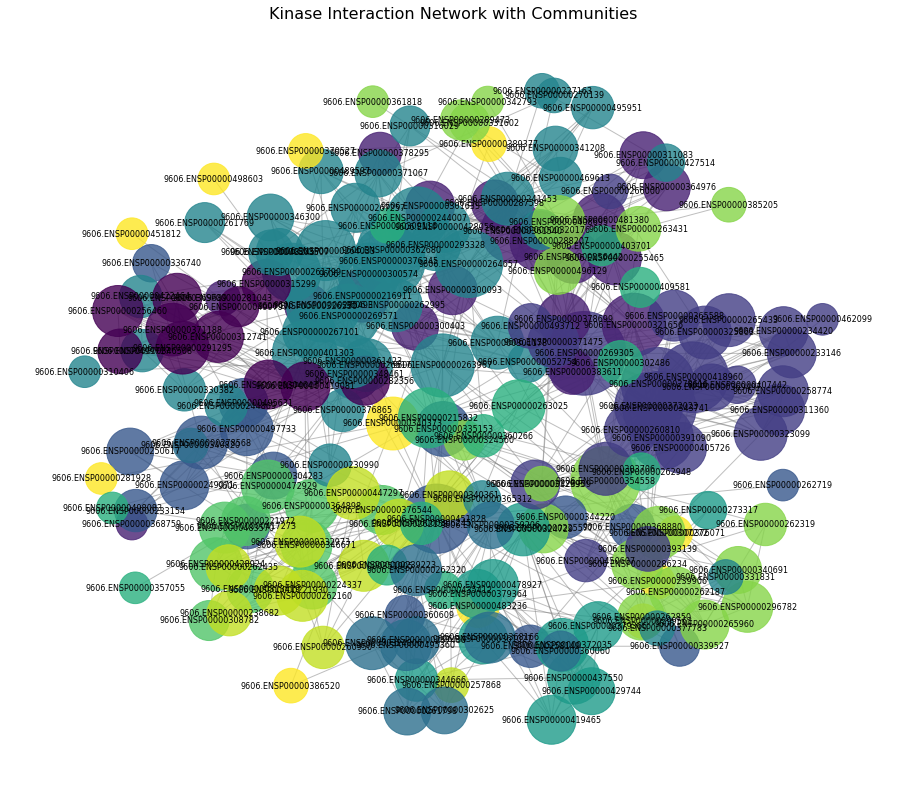

In [23]:
# Fix: Generate node sizes to match the number of nodes
node_sizes = [800 + 200 * graph.degree(n) for n in graph.nodes]  # Updated to graph.nodes
colors = [partition.get(node, 0) for node in graph.nodes]  # Default color if no partition found

# Draw the graph
plt.figure(figsize=(16, 14))
nx.draw_networkx_nodes(
    graph,
    pos,
    node_size=node_sizes,
    node_color=colors,
    cmap=cm.get_cmap("viridis"),
    alpha=0.8
)
nx.draw_networkx_edges(graph, pos, edge_color="gray", alpha=0.5)
nx.draw_networkx_labels(graph, pos, font_size=8, font_color="black", font_family="sans-serif")

# Add title and display
plt.title("Kinase Interaction Network with Communities", fontsize=16)
plt.axis("off")
plt.show()


In [24]:
# Step 3: Save Community Results
community_df = pd.DataFrame(list(partition.items()), columns=["Node", "Community"])
output_file = 'community_results.csv'
community_df.to_csv(output_file, index=False)
print(f"Community results saved to {output_file}")

Community results saved to community_results.csv


In [25]:
# Install gprofiler-official for enrichment analysis
!pip install gprofiler-official

In [28]:
print(protein_list[:10])  # Check the first 10 entries

['9606.ENSP00000216911', '9606.ENSP00000288207', '9606.ENSP00000368759', '9606.ENSP00000301633', '9606.ENSP00000378295', '9606.ENSP00000361540', '9606.ENSP00000300093', '9606.ENSP00000326550', '9606.ENSP00000281043', '9606.ENSP00000269305']


In [29]:
# Install mygene library
!pip install mygene

In [26]:
from gprofiler import GProfiler

# Step 1: Extract all proteins from the graph
protein_list = [node for node in graph.nodes if not node.startswith("Kinase")]

# Step 2: Perform Enrichment Analysis
gp = GProfiler(return_dataframe=True)
enrichment_results = gp.profile(organism="hsapiens", query=protein_list)

# Step 3: Save Enrichment Results
output_file = 'enrichment_results.csv'
enrichment_results.to_csv(output_file, index=False)
print(f"Enrichment results saved to {output_file}")


Enrichment results saved to enrichment_results.csv


In [31]:
from mygene import MyGeneInfo

mg = MyGeneInfo()

# Ensure protein_list is defined properly
if "protein_list" not in locals():
    raise ValueError("protein_list is not defined. Ensure it contains valid Ensembl protein IDs.")

# Map Ensembl protein IDs to HGNC gene symbols
query_ids = list(protein_list)  # Convert to list if not already
results = mg.querymany(query_ids, scopes="ensembl.protein", fields="symbol", species="human", returnall=True)

# Extract mapped symbols, handling missing cases
mapped_proteins = [res["symbol"] for res in results["out"] if "symbol" in res]

# Identify missing mappings
unmapped_proteins = [res["query"] for res in results["out"] if "symbol" not in res]

# Print first 10 mapped symbols
print("Mapped Proteins (first 10):", mapped_proteins[:10])

# Print summary of unmapped queries
if unmapped_proteins:
    print(f"{len(unmapped_proteins)} input query terms found no hit.")
    print("Example missing mappings:", unmapped_proteins[:10])


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
205 input query terms found no hit:	['9606.ENSP00000216911', '9606.ENSP00000288207', '9606.ENSP00000368759', '9606.ENSP00000301633', '96


Mapped Proteins (first 10): []
205 input query terms found no hit.
Example missing mappings: ['9606.ENSP00000216911', '9606.ENSP00000288207', '9606.ENSP00000368759', '9606.ENSP00000301633', '9606.ENSP00000378295', '9606.ENSP00000361540', '9606.ENSP00000300093', '9606.ENSP00000326550', '9606.ENSP00000281043', '9606.ENSP00000269305']


In [32]:
from gprofiler import GProfiler

# Ensure graph is defined
if "graph" not in locals():
    raise ValueError("graph is not defined. Ensure it contains nodes representing proteins.")

# Step 1: Extract all proteins from the graph (excluding Kinase nodes)
protein_list = [node for node in graph.nodes if not node.startswith("Kinase")]

# Check if the protein list is not empty
if not protein_list:
    raise ValueError("No valid proteins found in the graph.")

# Step 2: Perform Enrichment Analysis
gp = GProfiler(return_dataframe=True)
try:
    enrichment_results = gp.profile(organism="hsapiens", query=protein_list)
except Exception as e:
    raise RuntimeError(f"Enrichment analysis failed: {e}")

# Step 3: Save Enrichment Results
output_file = "enrichment_results.csv"
enrichment_results.to_csv(output_file, index=False)
print(f"Enrichment results saved to {output_file}")

Enrichment results saved to enrichment_results.csv


In [37]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\Tim\kinase_interactions.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kinase             869 non-null    object 
 1   Source Protein     869 non-null    object 
 2   Target Protein     869 non-null    object 
 3   Interaction Score  869 non-null    float64
dtypes: float64(1), object(3)
memory usage: 27.3+ KB


(None,
   Kinase        Source Protein        Target Protein  Interaction Score
 0  AURKA  9606.ENSP00000216911  9606.ENSP00000288207              0.988
 1  AURKA  9606.ENSP00000216911  9606.ENSP00000368759              0.990
 2  AURKA  9606.ENSP00000216911  9606.ENSP00000301633              0.993
 3  AURKA  9606.ENSP00000216911  9606.ENSP00000378295              0.994
 4  AURKA  9606.ENSP00000216911  9606.ENSP00000361540              0.995)

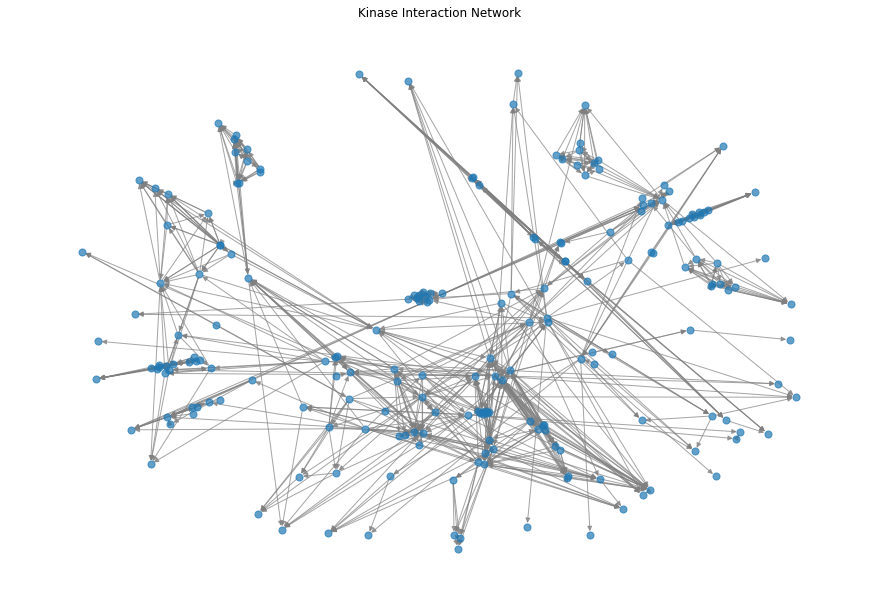

(205, 795)

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.from_pandas_edgelist(df, source="Source Protein", target="Target Protein", edge_attr="Interaction Score", create_using=nx.DiGraph())

# Draw the network
plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=False, node_size=50, edge_color="gray", alpha=0.7)
plt.title("Kinase Interaction Network")
plt.show()

# Basic network statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

num_nodes, num_edges

In [39]:
# Compute betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Sort kinases by importance
top_kinases = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

# Display the top 10 kinases with highest betweenness centrality
top_kinases

[('9606.ENSP00000269305', 0.013998875412233859),
 ('9606.ENSP00000264657', 0.008186435493737723),
 ('9606.ENSP00000275493', 0.004571541260182234),
 ('9606.ENSP00000354558', 0.004223815963166877),
 ('9606.ENSP00000335153', 0.004152983032293378),
 ('9606.ENSP00000278616', 0.003828485417155368),
 ('9606.ENSP00000401303', 0.003765011751827168),
 ('9606.ENSP00000451828', 0.003308219839660002),
 ('9606.ENSP00000361423', 0.0030039602047715643),
 ('9606.ENSP00000321656', 0.0029723383606316076)]

In [40]:
from mygene import MyGeneInfo

mg = MyGeneInfo()
query_ids = ["9606.ENSP00000269305", "9606.ENSP00000264657", "9606.ENSP00000275493"]  # Add your IDs
results = mg.querymany(query_ids, scopes="ensembl.protein", fields="symbol", species="human")

# Extract symbols
mapped_kinases = {res["query"]: res.get("symbol", "Not Found") for res in results}
print(mapped_kinases)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
3 input query terms found no hit:	['9606.ENSP00000269305', '9606.ENSP00000264657', '9606.ENSP00000275493']


{'9606.ENSP00000269305': 'Not Found', '9606.ENSP00000264657': 'Not Found', '9606.ENSP00000275493': 'Not Found'}


In [42]:
import networkx as nx
import community as community_louvain

# Compute Louvain partition
partition = community_louvain.best_partition(G.to_undirected())

# Add community labels to nodes
nx.set_node_attributes(G, partition, "community")

# Count the number of detected clusters
num_clusters = len(set(partition.values()))
print(f"Number of detected functional clusters: {num_clusters}")

Number of detected functional clusters: 12


In [43]:
# Compute degree centrality (importance based on connections)
degree_centrality = nx.degree_centrality(G)

# Sort proteins by degree centrality
top_hubs = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

# Display the top 10 most connected proteins
print("Top 10 Hub Proteins (Highly Connected Nodes):")
for protein, centrality in top_hubs:
    print(f"{protein}: {centrality:.4f}")

Top 10 Hub Proteins (Highly Connected Nodes):
9606.ENSP00000269305: 0.1520
9606.ENSP00000275493: 0.1176
9606.ENSP00000343741: 0.1127
9606.ENSP00000278616: 0.1127
9606.ENSP00000376345: 0.1078
9606.ENSP00000418960: 0.1029
9606.ENSP00000451828: 0.0980
9606.ENSP00000354558: 0.0980
9606.ENSP00000362680: 0.0931
9606.ENSP00000372023: 0.0931


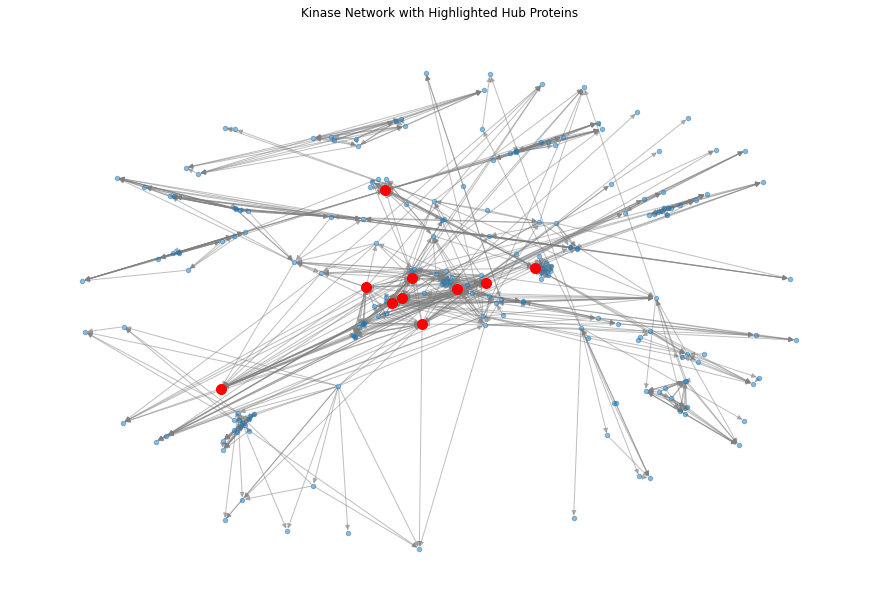

In [45]:
import matplotlib.pyplot as plt

# Get the top 10 hub proteins
top_hub_nodes = [node for node, _ in top_hubs]

# Draw network with highlighted hubs
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # Layout for visualization
nx.draw(G, pos, node_size=20, edge_color="gray", alpha=0.5, with_labels=False)

# Highlight top hub nodes
nx.draw_networkx_nodes(G, pos, nodelist=top_hub_nodes, node_color="red", node_size=100)

plt.title("Kinase Network with Highlighted Hub Proteins")
plt.show()

In [48]:
import pandas as pd

# Load kinase interactions
kinase_df = pd.read_csv(r"C:\Users\Tim\kinase_interactions.csv")

# Display first few rows
print(kinase_df.head())

  Kinase        Source Protein        Target Protein  Interaction Score
0  AURKA  9606.ENSP00000216911  9606.ENSP00000288207              0.988
1  AURKA  9606.ENSP00000216911  9606.ENSP00000368759              0.990
2  AURKA  9606.ENSP00000216911  9606.ENSP00000301633              0.993
3  AURKA  9606.ENSP00000216911  9606.ENSP00000378295              0.994
4  AURKA  9606.ENSP00000216911  9606.ENSP00000361540              0.995


In [50]:
# Load Excel file
top_20_df = pd.read_excel(r"C:\Users\Tim\OneDrive\Documents\Copy of TOP_20_FOR_STRUCTURE(1).xlsx")

# Display first few rows
print(top_20_df.head())


   KINASE                                              FASTA
0   AURKA  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...
1    PAK1  MSNNGLDIQDKPPAPPMRNTSTMIGAGSKDAGTLNHGSKPLPPNPE...
2  PDGFRB  MRLPGAMPALALKGELLLLSLLLLLEPQISQGLVVTPPGPELVLNV...
3     LYN  MGCIKSKGKDSLSDDGVDLKTQPVRNTERTIYVRDPTSNKQQRPVP...
4    EGFR  MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...


In [ ]:
# Merge the two dataframes based on the 'Kinase' column
merged_data = pd.merge(interaction_data, fasta_data, on='Kinase', how='inner')

# Display the merged dataframe
print(merged_data.head())